# This code analyzes LAHM heatng profiles
July 2026

In [4]:
# Generic resources
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
from scipy import optimize

# Local imports
import LAHM_library as LL

In [5]:
%matplotlib inline
%pwd

'/home/chemistry/LAI_in_snow/LAHM'

In [6]:
# Instrument factors
myLAHM_Parameters = LL.LAHM_Parameters(inst_number = 10) # 20 is for Lucy's LAHM
myLAHM_Parameters.report()

Parameters:
LAHM unit = 10
inst_factor = 0.77
exponential_prefactor = 3.43
temperature_factor = 0.238
ugbasic_offset = 3.0


In [7]:
# Graphics parameters
# figwidth = 25
# figheight = 12
fontsize = 12

In [11]:
# Samples measured on the UPS LAHM
# foldername = 'Cascades (UCB UPS UPS)/Adams/'; filelist = 'filelist.txt'
# foldername = 'Cascades (UCB UPS UPS)/Baker/'; filelist = 'filelist.txt'
# foldername = 'Cascades (UCB UPS UPS)/Misc/'; filelist = 'filelist.txt'
# foldername = 'Cascades (UCB UPS UPS)/Rainier/'; filelist = 'filelist.txt'

# Samples measured on the UCB LAHM (but analyzed at UPS)
# foldername = 'Cascades (UCB UCB UPS)/'; filelist = 'filelist_Adams.txt'
# foldername = 'Cascades (UCB UCB UPS)/'; filelist = 'filelist_Baker.txt'
# foldername = 'Cascades (UCB UCB UPS)/'; filelist = 'filelist_Columbia.txt'
# foldername = 'Cascades (UCB UCB UPS)/'; filelist = 'filelist_Rainier.txt'

# Samples taken by the UPS team, measured on the UPS LAHM, and analyzed at UPS
# foldername = 'Rainier (UPS UPS UPS)/'; filelist = 'filelist_site_1.txt'
# foldername = 'Rainier (UPS UPS UPS)/'; filelist = 'filelist_site_7.txt'
# foldername = 'Rainier (UPS UPS UPS)/'; filelist = 'filelist_all.txt'

# Not sure about the status of these 
foldername = 'Trial runs/'; filelist = 'filelist.txt'
# foldername = 'LAHM Data Summer 2025/'; filelist = 'filelist.txt'

In [12]:
# Name of the master file with all the filenames and the volumes
filename = foldername+filelist

In [17]:
# Read in the master file
line0_list, number = LL.getline0list(filename)
print('number = ', number)
for i in range(number):
    line0_list[i] = foldername+line0_list[i]
    print(line0_list[i])

# Run the original Schmitt analysis
myTtrace_list = LL.getgpg(line0_list, myLAHM_Parameters,verbose=True)
for i in range(0,number):
    print('')
    print('Working on i = ', i)
    myTtrace = myTtrace_list[i]
    myTtrace.report()

Trial runs/filelist.txt
number =  2
Trial runs/Millipore blank.txt 100
Trial runs/LAHM_test_data.txt 100
From getgpg: number =  2
From getgpg: t =  0
From getgpg:  ['Trial', 'runs/Millipore', 'blank.txt', '100']
From getgpg: filename2 =  Trial runs/Millipore blank.txt
From getgpg: vol[t] =  100.0
From getgpg: t =  1
From getgpg:  ['Trial', 'runs/LAHM_test_data.txt', '100']
From getgpg: filename2 =  Trial runs/LAHM_test_data.txt
From getgpg: vol[t] =  100.0

Working on i =  0
Trial runs/Millipore blank.txt 100.0 7.175544926924737 0.7175544926924737

Working on i =  1
Trial runs/LAHM_test_data.txt 100.0 123.40089488602221 12.34008948860222


Trial runs/Millipore blank.txt
Trial runs/LAHM_test_data.txt


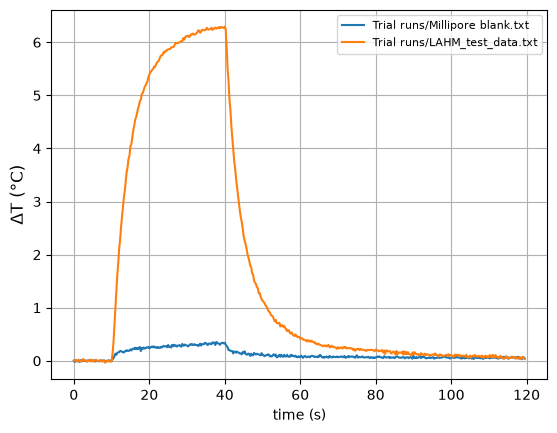

In [18]:
# Makes heating curve/Mean Temp Increase graph
# Plot all the traces
# plt.figure(figsize=(figwidth, figheight))
# plt.figure(dpi=500)
plt.figure()
mylabel_List = []
for i in range(number): 
    myTtrace = myTtrace_list[i]
   # mylabel = myTtrace.filename+', '+str(myTtrace.ugbasic)[0:4]+'$\ \mu g$'+', '+str(myTtrace.volume)[0:4]+' mL'
    mylabel = myTtrace.filename
    print(mylabel)
    mylabel_List.append(mylabel)
    plt.plot(myTtrace.time, myTtrace.Temp_av, label=mylabel) 
#plt.ylabel('Mean temp increase ($^\circ$C)')
plt.ylabel(r'$\Delta$T ($\degree$C)',fontsize=fontsize)
plt.xlabel('time (s)')
plt.legend(loc='upper right',fontsize=8)
plt.grid(True)
plt.show()

In [19]:
#makes Delta T graph
## Loops through file list and graphs
#True = want to see every graph
graphs = False

A_array = np.zeros(number)
t0_array = np.zeros(number)
A1_array = np.zeros(number)
t01_array = np.zeros(number)
A2_array = np.zeros(number)
t02_array = np.zeros(number)
theorylabel_List = []
plt.figure(dpi=500)

for i in range(number):

    print('')
    print('Working on i = ', i)

    myTtrace = myTtrace_list[i]
    myTtrace.report()
    
    # Extract from when it starts to rise
    Temp_expt = myTtrace.Temp_av[40:160]
    time_expt = myTtrace.time[40:160]-myTtrace.time[40]

    # Do a 2-parameter fit
    params, params_covariance = optimize.curve_fit(LL.test_func, time_expt, Temp_expt, p0=[2, 3])
    A_array[i]=params[0]
    t0_array[i]=params[1]

    # # Do a 4-parameter fit
    # params2, params2_covariance = optimize.curve_fit(test_func2, time_expt, Temp_expt, p0=[2, 5, 2 ,5], bounds=(0, 100))
    # A1_array[i]=params2[0]
    # t01_array[i]=params2[1]
    # A2_array[i]=params2[2]
    # t02_array[i]=params2[3]

    if graphs:
        theory = LL.test_func(time_expt,params[0],params[1])
        # theory2 = LL.test_func2(time_expt,params2[0],params2[1],params2[2],params2[3])
        exptlabel = mylabel_List[i]

        # plt.figure(dpi=200)
        plt.plot(time_expt,Temp_expt,'+',label=exptlabel)
        theorylabel = '$A(1-e^{-t/t_0})$'+'  A='+str(params[0])[0:6]+'  t0='+str(params[1])[0:6]
        print(theorylabel)
        theorylabel_List.append(theorylabel)
        plt.plot(time_expt,theory, color= 'black')
        # plt.plot(time_expt,theory2, color= 'black',alpha=.5)
        plt.ylabel(r'$\Delta$T ($\degree$C)',fontsize=fontsize)
        plt.xlabel('time (s)')
        plt.legend()
        plt.grid(True)
plt.show()


Working on i =  0
Trial runs/Millipore blank.txt 100.0 7.175544926924737 0.7175544926924737

Working on i =  1
Trial runs/LAHM_test_data.txt 100.0 123.40089488602221 12.34008948860222


<Figure size 3200x2400 with 0 Axes>

### Below is a listing of three main parameters
Loading in $\micro$ grams, loading in ${ng \over g}$, $t_0$, 

### Notice!
The numbers below are what we are focusing on. After that are diagnostic tests.

In [20]:
print('')
print('Results:')
print('file, ugbasic, ngperg, t0')
for i in range(number):
    ugbasic = myTtrace_list[i].ugbasic
    ngperg = myTtrace_list[i].ngperg
    t0 = t0_array[i]
    myTtrace = myTtrace_list[i]
    mylabel = myTtrace_list[i].filename
    print(mylabel,ugbasic,ngperg,t0)


Results:
file, ugbasic, ngperg, t0
Trial runs/Millipore blank.txt 0.7175544926924737 7.175544926924737 4.387726069001984
Trial runs/LAHM_test_data.txt 12.34008948860222 123.40089488602221 4.9689977074842115


In [11]:
# # writes data into output.txt file
# f2 = open('output.txt', 'w')
# #header
# f2.write('file         \t \t A \t   t0\n')

# # write the data as float values with a tab between them
# for i in range(number):
#     f2.write('%s    %f    %f\n' % (myTtrace_list[i].filename, A_array[i],t0_array[i]))

# f2.close()

In [12]:
# # Copy micrograms into a new array "microg" from myTtrace_List
# microg = np.zeros(number)
# for i in range(number):
#     print(myTtrace_list[i].ugbasic)
#     microg[i] = myTtrace_list[i].ugbasic

# # Print in the order they come
# print("microg before sorting = ",microg)

# # Find the indices of the microgram array in ascending order
# sort_index = np.argsort(microg); print('Microgram indices in increasing order =', sort_index)

# # Make new arrays of Schmitt's micrograms and A-values, in ascending order of micrograms
# microg_sorted = microg[sort_index]; print("microg after sorting = ",microg_sorted)
# A_array_sorted = A_array[sort_index]; print("A-values after sorting = ",A_array_sorted)

# # Examining correlation between A and Schmitt's micrograms
# print(number)
# if number > 2: 
    
#     # Plot A values as a function of Schmitt's values
#     # plt.figure(figsize=(figwidth, figheight))
#     plt.figure()
#     plt.plot(A_array_sorted, microg_sorted, 'o', color= 'magenta', label='obs')
#     plt.grid(True)
    
#     # Do a fit
#     maxorder = 2
#     if number > 2:
#         fit_order = np.min((maxorder,number)); print('fit order = ',fit_order)
#         p = np.polyfit(A_array_sorted, microg_sorted, fit_order); print('p = ',p)
#         A_dense = np.linspace(np.min(A_array), np.max(A_array))
#         microg_polyval = np.polyval(p, A_dense)
#         plt.plot(A_dense, microg_polyval, '--',label='fit')
#         plt.ylabel('Loading (ug) (Schmitt et al method)') 
#         plt.xlabel('Asymptotic DeltaT')
#     plt.legend()
#     plt.show()
    
#     print('t0 ranges from ', np.min(t0_array),np.max(t0_array))

# #making sure we aren't crazy
# print(A_array_sorted)
# print('i  loading from A  Schmitts loading')

# if number > 2:
#     LoadingFromA = p[2] + p[1]* A_array_sorted + p[0]*A_array_sorted**2
#     for i in range(number):
#         print(i, LoadingFromA[i], microg_sorted[i])
#     # loading as calculated from A and Schmitt's loading agree, telling us that asymptotic A is a good proxy for t[160] (see LAHM_library) for the same material

# # Examining correlation between A and Schmitt's micrograms

# if number > 2: 
    
#     # Plot A values as a function of Schmitt's values
#     # plt.figure(figsize=(figwidth, figheight))
#     plt.plot(microg_sorted, A_array_sorted,'o', color= 'magenta', label='obs')
#     plt.grid(True)
    
#     # Do a fit
#     maxorder = 2
#     if number > 2:
#         fit_order = np.min((maxorder,number)); print('fit order = ',fit_order)
#         p = np.polyfit(microg_sorted, A_array_sorted,fit_order); print('p = ',p)
#         microg_dense = np.linspace(np.min(microg),np.max(microg))
#         A_polyval = np.polyval(p,microg_dense)
#         plt.plot(microg_dense,A_polyval,'--',label='fit')
#         plt.xlabel('Loading (ug) (Schmitt et al)') 
#         plt.ylabel('Asymptotic Delta T (assuming exponential form)')
#     plt.legend()
#     plt.show()
    
#     print('t0 ranges from ', np.min(t0_array),np.max(t0_array))